In [221]:
%load_ext pretty_jupyter

The pretty_jupyter extension is already loaded. To reload it, use:
  %reload_ext pretty_jupyter


## Data Preprocessing using Python

When working with a new dataset, whether you're preparing it for analysis, machine learning modelling, or regression tasks, the first and most crucial step is data preprocessing. This process ensures the dataset is clean, consistent, and ready for accurate insights. Data preprocessing involves exploring the data, addressing missing values, detecting outliers, and transforming variables to appropriate formats where necessary.

This section will walk through step-by-step procedures for data exploration and exploratory data analysis (EDA) using **Python**. We’ll use core libraries such as `pandas` for data manipulation and `lets_plot` for visualizing distributions and relationships. Additionally, we’ll utilize tools like `sklearn.impute` to manage missing values effectively.

Following this guide, you will gain a solid understanding of foundational data preprocessing and EDA techniques. In particular we will cover the following issues which arise in almost all empirical projects:

* Loading a dataset
* Exploratory descriptive and graphical analysis 
* Dealing with missing values

## Preparing your workspace

We begin by importing the necessary libraries.

In [222]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lets_plot import *
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats import skew, kurtosis

# Lets_plot requires a setup
LetsPlot.setup_html()

## Loading a dataset

Let's get a dataset to explore. We shall use the [Kaggle Credit Test dataset](https://www.kaggle.com/datasets/parisrohan/credit-score-classification/data), including 50,000 observations (rows) and 27 variables (columns). You can access the data file from here: [Kaggle_credit_test.csv](https://github.com/datasquad/ECLR/blob/gh-pages/data/Kaggle_credit_test.csv).  You can download the file by clicking on the "Download" symbol. This particular dataset includes financial and behavioural attributes of customers, such as income, debt, and payment habits. The variables included in the dataset and their description are as follows:

- `ID`: Unique identifier for each record.
- `Customer_ID`: Identifier for individual customers.
- `Month`: The month associated with the record.
- `Name`: Customer name.
- `Age`: Age of the customer.
- `SSN`: Social Security Number (likely pseudonymized).
- `Occupation`: Job or profession of the customer 
- `Annual_Income`: Annual income of the customer.
- `Monthly_Inhand_Salary`: Calculated monthly salary in hand.
- `Num_Bank_Accounts`: Number of bank accounts the customer owns.
- `Num_Credit_Cards`: Number of credit cards the customer owns.
- `Interest_Rate`: Interest rate applied to the customer’s accounts.
- `Num_of_Loan`: Number of loans taken by the customer.
- `Delay_from_due_date`: Average delay in payments (in days).
- `Num_of_Delayed_Payment`: Number of delayed payments.
- `Changed_Credit_Limit`: Whether the credit limit has changed (and by how much).
- `Num_Credit_Inquiries`: Number of inquiries into the customer’s credit history.
- `Credit_Mix`: Quality of credit mix (e.g., "Good").
- `Outstanding_Debt`: Total outstanding debt.
- `Credit_Utilization_Ratio`: Percentage of available credit utilized.
- `Credit_History_Age`: Length of credit history (e.g., "22 Years and 9 Months").
- `Payment_of_Min_Amount`: Whether the minimum payment was made (e.g., "Yes", "No").
- `Total_EMI_per_month`: Total Equated Monthly Installments (EMI).
- `Amount_invested_monthly`: Monthly investment amount.
- `Payment_Behaviour`: Customer payment behaviour pattern.
- `Monthly_Balance`: Remaining balance at the end of the month.

There is no information on the source of the data available, but as you will be able to see below, these data are randomly generated data. Which is of course just right as we should otherwise not be able to get a dataset with name and social security numbers.

If you downloaded the data file ensure that it is in your working directory and that you set the working directory correctly. If you are unsure where your current working directory is check it like this. 

In [223]:
print("Current Working Directory:", os.getcwd())

Current Working Directory: C:\Pycode


If you need to change the working directory change it in this way.

In [224]:
os.chdir("C:/Pycode")  # Replace with your desired path
print("New Working Directory:", os.getcwd())

New Working Directory: C:\Pycode


If you have downloaded the file into your working directory you can load it using `credit_data = pd.read_csv("Kaggle_credit_test.csv")`. But you can also access the file directly as in the next line.

In [225]:
# Load the CSV file
credit_data = pd.read_csv("https://raw.githubusercontent.com/datasquad/ECLR/refs/heads/gh-pages/data/Kaggle_credit_test.csv")

URLError: <urlopen error [Errno 11001] getaddrinfo failed>

## Data Preparation

In Python, several tools are available to explore and understand the characteristics of a dataset. These tools allow for a comprehensive examination of the structure, content, and summary statistics of the data, which is crucial for effective data analysis. Let's begin by using the `shape` function to obtain the dimensions of our dataset.

In [59]:
# investigate the shape of the DataFrame (dimensions)
credit_data.shape

(50000, 27)

The `shape` function returns a tuple, indicating that the `number of rows` is equal to 50,000 (data points or observations)  and the `number of columns` is equal to 27 (features or variables). 

Running now the `head()` command on the dataset we get a display of the first few rows of data to understand its structure. Try what happens if you just call `credit_data.head()`.

In [60]:
# Display the first few rows of the dataset
credit_data.head(6)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923
5,0x1617,CUS_0x21b1,October,Rick Rothackerj,28,#F%$D@*&8,Teacher,34847.84,3037.986667,2,...,5.0,Good,605.03,30.116600,27 Years and 4 Months,No,18.816215,251.62736875017606,Low_spent_Large_value_payments,303.3550833433617


 > You will have noticed that when running a command like `head()` on a large DataFrame, you can see an output where the list of columns or rows is truncated with `....` This happens because Pandas limits the display of rows and columns by default to make the output more manageable.

Since this dataframe has a lot of columns we can run the `.columns` method to see all their names:

In [61]:
# Display all column names
credit_data.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

Now, it would be important to examine the data type that `pandas` has inferred for each column in the dataset. This involves running the  `info()` method. Understanding the data types is crucial, as they determine how the data can be manipulated and analyzed.  Ensuring that the data types align with the intended use of each variable is an important step in the data preprocessing process, as incorrect data types can lead to errors or unexpected behaviour in subsequent analyses.

> It is worth noting that in a pandas DataFrame, every column is actually a **Series**, and each Series has its own data type. To explore these data types further, we can use the `.dtypes` attribute, which provides just column names and datatypes.

> Python differentiates between **methods** and **attributes**. Here `.info()` is a method applied to the `credit_data` dataframe. `.info()` is a function which is associated with dataframes and in this example applied to `credit_data`.  An attribute (or characteristic) of an objet is called without the `()` at the end. Here `.dtypes` is an attribute of the dataframe. It turns out that both `.info()` and `.dtypes` deliver almost identical information and sometimes it is not immediately obvious whether something is a method or an attribute.

In [62]:
# Display dataset info
credit_data.info()
# credit_data.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

Running the `info()` command we can see that the the dataset has **19 columns** of type `object`** (typically strings or mixed types), **4 columns of type `float64`** (decimal numbers), and **4 columns of type `int64`** (integer numbers). Moreover, you may have noticed that some columns like `Age`, `Annual_Income` and `Num_of_Loan` are represented as an object despite being inherently numerical!

### Non-numeric characters in mumeric columns?

As we explore our data, we can see that `Age`, `Annual_Income`, `Num_of_Loan` and `Amount_invested_monthly` contain **non-numeric characters**. For instance, `Age` contains **"32_"** in one row instead of an integer. 

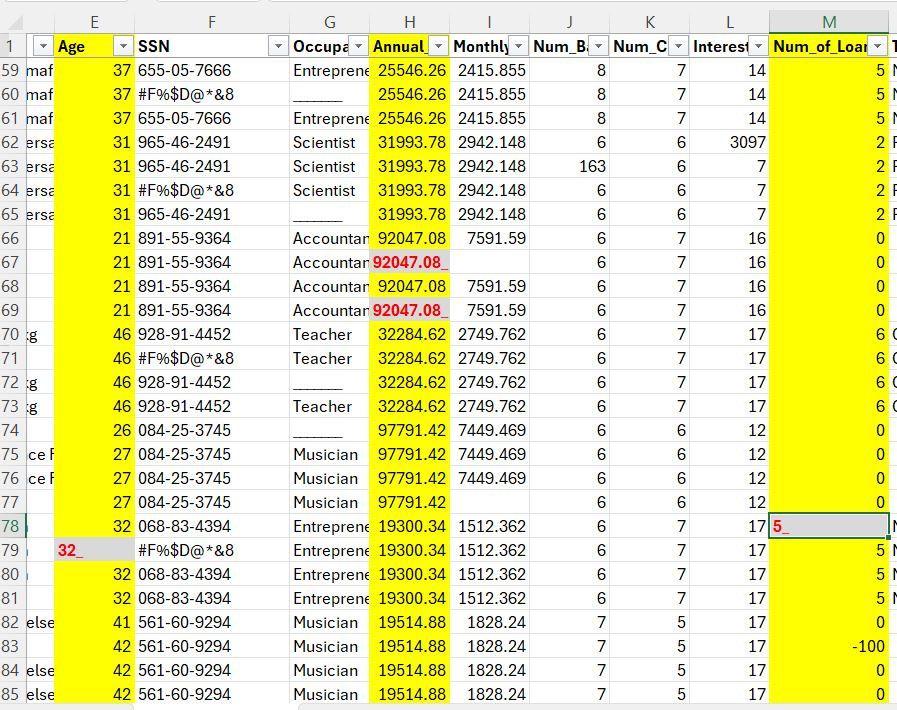

To clean columns like `Age`, `Annual_Income`, `Num_of_Loan` and `Amount_invested_monthly` where characters like underscores `(_)` appear after numeric values, we can use **string manipulation methods** to remove these unwanted characters and convert the columns to numeric types. In the code below we first define s small function `clean_numeric_column` which we then apply to columns `Age`, `Annual_Income` and `Num_of_Loan`. 

Let's run the code before we comment a little more afterwards.

In [ ]:
# Define a function to clean numeric columns with unwanted characters
def clean_numeric_column(column):
    # Remove non-numeric characters like '_'
    return column.str.replace(r'[^0-9.]', '', regex=True).astype(float)

# Create a copy of the original credit_data to clean and save as datawithoutimputation
datawithoutimputation = credit_data.copy()

# Clean the 'Age' column
datawithoutimputation['Age'] = clean_numeric_column(datawithoutimputation['Age'])

# Clean the 'Annual_Income' column
datawithoutimputation['Annual_Income'] = clean_numeric_column(datawithoutimputation['Annual_Income'])

# Clean the 'Num_of_Loan' column
datawithoutimputation['Num_of_Loan'] = clean_numeric_column(datawithoutimputation['Num_of_Loan'])

# Clean the 'Num_of_Delayed_Payment' column
datawithoutimputation['Num_of_Delayed_Payment'] = clean_numeric_column(datawithoutimputation['Num_of_Delayed_Payment'])

# Clean the 'Num_of_Delayed_Payment' column
datawithoutimputation['Amount_invested_monthly'] = clean_numeric_column(datawithoutimputation['Amount_invested_monthly'])


# Verify the cleaning by checking the data types and first few rows
print("Data types after cleaning:")
print(datawithoutimputation[['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment','Amount_invested_monthly']].dtypes)

print("\nFirst few rows after cleaning:")
print(datawithoutimputation[['Age', 'Annual_Income', 'Num_of_Loan','Num_of_Delayed_Payment','Amount_invested_monthly']].head())


Data types after cleaning:
Age                        float64
Annual_Income              float64
Num_of_Loan                float64
Num_of_Delayed_Payment     float64
Amount_invested_monthly    float64
dtype: object

First few rows after cleaning:
    Age  Annual_Income  Num_of_Loan  Num_of_Delayed_Payment  \
0  23.0       19114.12          4.0                     7.0   
1  24.0       19114.12          4.0                     9.0   
2  24.0       19114.12          4.0                     4.0   
3  24.0       19114.12          4.0                     5.0   
4  28.0       34847.84          1.0                     1.0   

   Amount_invested_monthly  
0               236.642682  
1                21.465380  
2               148.233938  
3                39.082511  
4                39.684018  


At the core of this operation is the following method: `.str.replace(r'[^0-9.]', '', regex=True).astype(float)`. The `.str.replace(r'[^0-9.]', '', regex=True)` part replaces everything but characters we expect in numbers (numbers 0 to 9 and decimal points) with nothing (`''`). The last part (`.astype(float)`) then defines the reslt of that first operation as a `float` datatype.

---
#### How to find the code?
[//]: # (-.- .tabset)

##### Use the community

You are not expected to know or remember all of the above from the top of your head. All you need to know is that Python can do this. In fact, when we wrote this we also had to check the details. This is especially true for the replacment of the nonnumerical characters. The data type setting is a command you will use often.

Here are two techniques of how to find solutions to your coding questions.

##### Search the internet

You could go to your favorite internet search engine and enter search terms as the following: "python pandas remove non-numeric characters from string". Everyone will get a slightly different list of links, but you are likely to quickly find either links to stackoverflow.com (which is a good place to go) or to documentation for python functions. The stackoverflow link we got gave, amongst others, the following example.

![Internet advice on replacing nonnumerical characters](../images/SO_replace.png)

If you compare the code here with the one we used above you can see that we merely adjusted the code we found here. Adapting such a solution to your problem is a very common activity as a coder.

##### Ask a GenAI engine

GenAI engines such as ChatGPT or Claude can help you out with coding problems. You need to start with a clear problem setup in order to get something useful.

![ChatGPT advice on renaming categorical variables](../images/ChatGPT_replace.png)

This image only shows the beginning of the answer proposed by ChatGPT. Not shown is a code example. You can then use the advice and adapt the code such that it works in your context.

#### 
[//]: # (-.- .unlisted .unnumbered)

---

> The  `str.replace()` method applies a regex pattern to replace unwanted characters. Then we have to specify the `r'[^0-9.]'`, which is a **regular expression (regex)** that matches any character that is not a digit (`0-9`) or a decimal point (`.`). The `''` replaces the matched characters with an empty string (effectively removing them). Then, setting the `regex=True` ensures that the function treats the pattern as a regex. 
When you work regularly with text you will come across regex frequently. It is basically a special type of language to identify certain text patterns. For instance: any word beginning with a "B" or "b". But how is that expressed in regex? Fortunately there is help at hand. There are a number of webpages that translate natural language into regex. [This is one we like.](https://www.subiregex.com/) Turns out that `\bB\w+` identifies all words beginning with "B".

Notice that we used `datawithoutimputation = data.copy()` to create a separate copy of the dataset. This ensures that any changes, such as cleaning, are applied only to `datawithoutimputation` and do not impact the original `credit_data`. This step is essential to ensure that we retain access to the original data.

In [ ]:
# Display newdataset info
datawithoutimputation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  float64
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  float64
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  float64
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

What you can see is that `Age`, `Annual_Income`, and `Num_of_Loan` are now of type `float64` (numeric).

### Identifying Missing values

Another important observation we can make here is that **missing values** are present in several key financial variables, which could impact downstream analysis and, therefore, would need careful handling. Let's now calculate the **number and percentage of missing values** for each column. 

In [ ]:
# Calculate missing values per variable
missing_values = credit_data.isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(credit_data)) * 100

# Combine into a DataFrame for better visualization
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

# Display the summary
print(missing_summary)

                          Missing Values  Percentage (%)
Monthly_Inhand_Salary               7498          14.996
Type_of_Loan                        5704          11.408
Name                                5015          10.030
Credit_History_Age                  4470           8.940
Num_of_Delayed_Payment              3498           6.996
Amount_invested_monthly             2271           4.542
Num_Credit_Inquiries                1035           2.070
Monthly_Balance                      562           1.124
Annual_Income                          0           0.000
Credit_Mix                             0           0.000
Payment_Behaviour                      0           0.000
Month                                  0           0.000
Total_EMI_per_month                    0           0.000
Payment_of_Min_Amount                  0           0.000
Age                                    0           0.000
Credit_Utilization_Ratio               0           0.000
Outstanding_Debt               

By using the `.isnull().sum()` function we are able to find the number of missing values per variable and then by setting `len(credit_data)) * 100` we get the percentage of missing values in each column. Let's focus on 4 specific variables namely `Monthly_Inhand_Salary`, `Num_Credit_Inquiries`, `Num_of_Delayed_Payment` and `Credit_History_Age`. Among the four variables, `Monthly_Inhand_Salary` has the highest percentage of missing values, with approximately **15%** of its data missing. Following this, `Credit_History_Age` has the second highest percentage of missing values at around **9%**. The `Num_of_Delayed_Payment` variable ranks third, with approximately **7%** of its values missing. Finally, `Num_Credit_Inquiries` has the smallest percentage of missing values, with only around **2%** of its data missing.

Indeed, just by exploring the csv file we get an indication that information is missing for those variables.

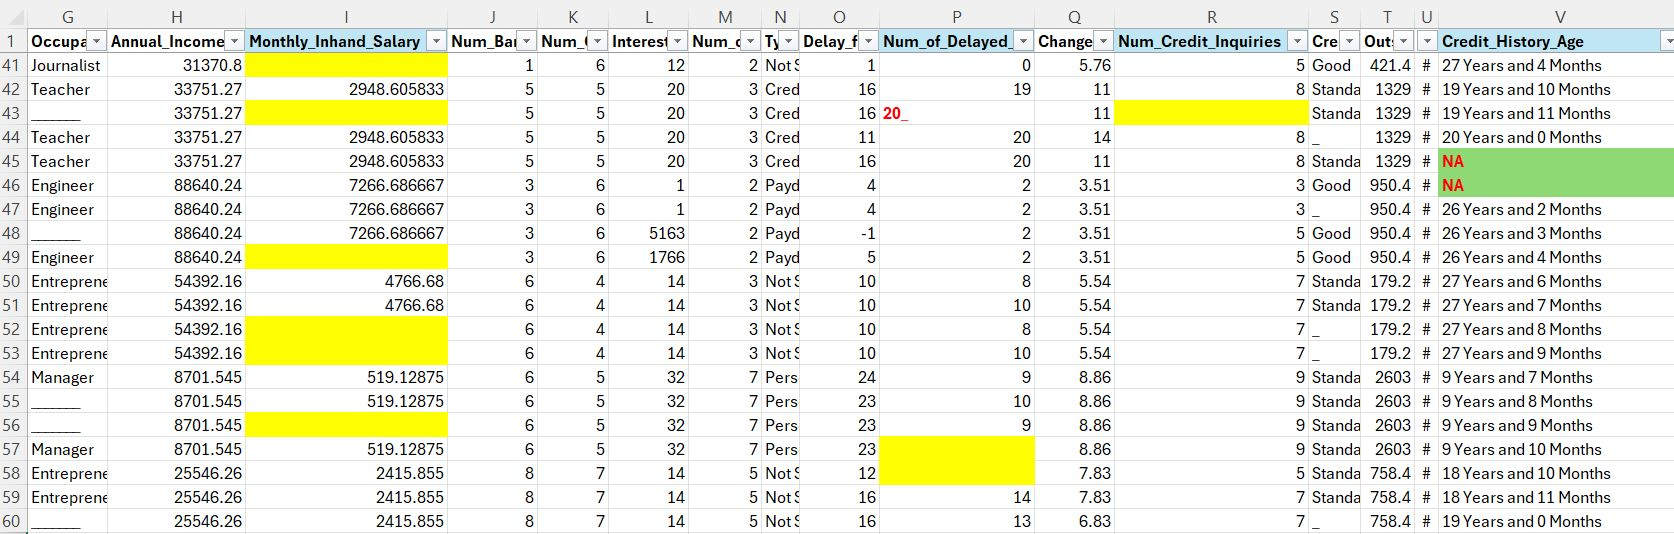

**What do you notice here?**

By exploring the data, we can observe that the `Num_of_Delayed_Payment` and `Credit_History_Age` columns contain more than just `blank cells` or `'NA'` values. The `Credit_History_Age` column contains **mixed types**, such as strings like `'27 years and 4 months'`.  This is why this two column is of type  `object`  rather than `float`.  On the contrary, the `Monthly_Inhand_Salary`, `Num_Credit_Inquiries`, contain missing values represented as blank cells in the dataset. They are of type `float` because the non-missing values are purely numeric.

Below we will discover additional aspects of missing data.

Let's focus on treating the non-numeric and mixed-type characters appearing in the `Credit_History_Age` column. 

The `Credit_History_Age` column contains mixed type characters, so we could extract the total number of months from the text format (e.g., `"27 years and 4 Months"` → `328 months`) and then convert it to a numeric type. We begin by writing a bespoke function which we then apply to the `Credit_History_Age` column.

In [195]:
# Function to convert 'Credit_History_Age' to total months
def convert_to_months(value):
    if pd.isnull(value):  # Handle missing values
        return None
    years = 0
    months = 0
    # Extract numeric parts 
    if 'year' in value.lower():
        years = int(value.lower().split('year')[0].strip())
    if 'month' in value.lower():
        months_part = value.lower().split('and')[-1].strip()
        months = int(months_part.split('month')[0].strip())
    return years * 12 + months

# Apply the function to the 'Credit_History_Age' column
datawithoutimputation['Credit_History_Age'] = datawithoutimputation['Credit_History_Age'].apply(convert_to_months)

The `convert_to_months` function splits the text into `years` and `months`, multiplies years by 12, and adds months to get the total.  The `if 'year' in value.lower()` function safely checks for the presence of the word `'year'` (case insensitive), then splits the string and extracts the numeric part before `'year'`. The same procedure occurs for `month` by using the  `if 'month' in value.lower()` command. 

Let's check now the "new"  `Credit_History_Age` column

In [196]:
# Check the result
print(datawithoutimputation['Credit_History_Age'].head())

0    273.0
1    274.0
2      NaN
3    276.0
4    327.0
Name: Credit_History_Age, dtype: float64


Now let's re-run the `info()` function to indicate whether the variables have now changed type.

In [197]:
# Display info for specific columns
selected_columns = ['Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age']
datawithoutimputation[selected_columns].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Monthly_Inhand_Salary   42502 non-null  float64
 1   Num_Credit_Inquiries    48965 non-null  float64
 2   Num_of_Delayed_Payment  46502 non-null  float64
 3   Credit_History_Age      45530 non-null  float64
dtypes: float64(4)
memory usage: 1.5 MB


---
#### How to understand code?
[//]: # (-.- .tabset)

##### The problem

The function we provided above (`convert_to_months`) converted text entries like "27 years and 4 Months" to a numeric variable measured in months. We tested that it did that. But you may still wonder how it did this. Previously we discussed how you can find solutions to problems like this (e.g. via stackoverflow.com or using AI engines like ChatGPT.) Even if it turns out that these solutions work, you should aspire to understand how the code works, as you may be able to use similar techniques in future without needing help. That is how good programmers learn.

##### Use AI

Go to your favorite Large Language Model (e.g. ChatGPT) and pose a question like the following:

![ChatGPT advice on renaming categorical variables](../images/ChatGPT_explain.png)

ChatGPT will give you step by step explanations of the function does. Note that the query included the full function but also made sure that it gave an example of the input into the function. Give ChatGPT a decent chance to explain what is happening.

##### Explore the code

The code contains certain steps which may be unfamiliar. Say you are not sure what happens in this line 'years = int(value.lower().split('year')[0].strip())'.



In [69]:
# define a test text
testtext = "27 years and 4 Months"

# what does .lower() do?
testtext.lower()

'27 years and 4 months'

As you can see this turned everything into lower case characters. This is useful for text operations such that you don't have to worry about whether something is lower or upper case.

In [70]:
# What does .split('year') do?
testtext.lower().split('year')

['27 ', 's and 4 months']

This has split the text to the part to the left of 'year' and the right of 'year'. The first entry is "27 ". It still contains a space.

In [71]:
#What does .strip() do?
testtext.lower().split('year')[0].strip()

'27'

This picked the first element (here "27 ", recall that [0] picks the first element) and then removed the space.

By building up the command step by step you can understand what has been done.



#### 
[//]: # (-.- .unlisted .unnumbered)

---

By applying appropriate data handling techniques `Credit_History_Age` was successfully converted from the `object` data type to `float`, ensuring it can now be used for numerical analysis.

In the data exploration and preparation stage, another critical step is identifying and handling **duplicates**. Duplicates can lead to biased insights or over-representation of specific data points, so detecting and addressing them ensures the integrity of the dataset for analysis.

In [ ]:
# Find duplicate rows
duplicates = credit_data[credit_data.duplicated()]

# Display duplicate rows (if any)
print(f"Number of duplicate rows: {duplicates.shape[0]}")
if not duplicates.empty:
    print("Duplicate rows:")
    print(duplicates)

Number of duplicate rows: 0


The `credit_data.duplicated()` command returns a **boolean Series** indicating whether each row is a duplicate while the `duplicates.shape[0]` displays the total count of duplicate rows. Here, we can see that there are no duplicate rows which basically sets the stage for accurate analysis and modelling. 

For now we shall leave missing data as missing. In a later section we demonstrate what you may want to do if you decided that you had to impute missing values, meaning replace them with some numerical values.

## Exploratory Data Analysis (EDA)

Let's move now into the Exploratory Data Analysis (EDA) phase which is also  a crucial step after data preparation. In this stage, we use various techniques to gain insights into the data, identify patterns, and understand relationships between variables.

Let's look into some descriptive statistics using the `describe()` function:

In [ ]:
# Summary statistics for numerical variables
datawithoutimputation.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly
count,50000.000000,5.000000e+04,42502.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,46502.000000,48965.000000,50000.000000,45530.000000,50000.000000,47729.000000
mean,118.994420,1.663342e+05,4182.004291,16.838260,22.921480,68.772640,11.299360,21.052640,30.910369,30.080200,32.279581,227.251175,1491.304305,641.654795
std,678.133254,1.351965e+06,3174.109304,116.396848,129.314804,451.602363,65.483498,14.860397,221.507473,196.984121,5.106238,99.554366,8595.647887,2053.895420
min,14.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,-5.000000,0.000000,0.000000,20.509652,10.000000,0.000000,0.000000
25%,25.000000,1.945333e+04,1625.188333,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,4.000000,28.061040,151.000000,32.222388,74.529270
50%,34.000000,3.757782e+04,3086.305000,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,7.000000,32.280390,225.000000,74.733349,135.590430
75%,43.000000,7.281702e+04,5934.189094,7.000000,7.000000,20.000000,6.000000,28.000000,18.000000,10.000000,36.468591,307.000000,176.157491,266.892228
max,8688.000000,2.413726e+07,15204.633333,1798.000000,1499.000000,5799.000000,1496.000000,67.000000,4399.000000,2593.000000,48.540663,408.000000,82398.000000,10000.000000


As you can see, `.describe()` provides statistics like `count`, `mean`, `standard deviation (std)`, `minimum (min)`, `maximum (max)`, and `percentiles` for numerical columns.

We can also control the decimal places and ask for summary statistics on particular columns as follows.

In [200]:
# Display the rounded summary
sel_columns = ['Annual_Income','Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age']
datawithoutimputation[sel_columns].describe().round(2)

,Annual_Income,Monthly_Inhand_Salary,Num_Credit_Inquiries,Num_of_Delayed_Payment,Credit_History_Age
count,50000.00,42502.00,48965.00,46502.00,45530.00
mean,166334.20,4182.00,30.08,30.91,227.25
std,1351965.47,3174.11,196.98,221.51,99.55
min,7005.93,303.65,0.00,0.00,10.00
25%,19453.33,1625.19,4.00,9.00,151.00
50%,37577.82,3086.30,7.00,14.00,225.00
75%,72817.02,5934.19,10.00,18.00,307.00
max,24137255.00,15204.63,2593.00,4399.00,408.00


Looking at the summary stats, which one is sticking out as worthy of investigation? The maximum value of the `Num_of_Delayed_Payment` variable is 4399 when the 75th percentile is 18. in the `Num_Credit_Inquiries` the maximum observation is 2593 which is also way larger than the remainder of the observations. Let's find that observation (using the max for `Num_of_Delayed_Payment` as an example).

We may also want to look at the `Annual_Income` where the max value is incredibly large at more than 24 million, although that could well be possible. We will return to this issue but park the issue for now.

In [ ]:
# find row with max value
sel1 = datawithoutimputation['Num_of_Delayed_Payment']==max(datawithoutimputation['Num_of_Delayed_Payment']) 
# find associated Customer ID
id1 = datawithoutimputation['Customer_ID'].loc[sel1] 
# select all rows with that customer id (need to select the particular value, id1.iloc[0])
test_sel1 = datawithoutimputation.loc[datawithoutimputation['Customer_ID'] == id1.iloc[0]].copy()

test_sel1.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
20688,0x1087a,CUS_0xb873,September,Guir,43.0,622-15-4188,Accountant,61262.76,NaN,6,...,12.0,Bad,2357.37,30.244376,84.0,Yes,250.596843,349.329400,!@9#%8,165.49675780818276
20689,0x1087b,CUS_0xb873,October,Guir,43.0,622-15-4188,Accountant,61262.76,5054.23,6,...,12.0,Bad,2357.37,29.800253,85.0,Yes,250.596843,208.639462,High_spent_Small_value_payments,306.1866952720153
20690,0x1087c,CUS_0xb873,November,NaN,43.0,622-15-4188,Accountant,61262.76,5054.23,6,...,12.0,Bad,2357.37,30.947312,86.0,Yes,250.596843,156.171171,High_spent_Medium_value_payments,348.6549864735926
20691,0x1087d,CUS_0xb873,December,Guir,43.0,622-15-4188,Accountant,61262.76,5054.23,6,...,12.0,_,2357.37,30.254765,87.0,Yes,250.596843,NaN,High_spent_Medium_value_payments,356.18551061590574


Let's look at these data. You can see that there are four observations for the same customer. The observations occur in four consecutive months (Sept to Dec). You can actually see that there are observations missing that could be easily completed, such as the `Name` in November, perhaps the `Monthly_Inhand_Salary` in Sept (as the Annual salary is the same as in the other months), the `Credit_Mix` variable (as there seem sot be no other substantial change). 

Returning to the issue of the unusually high `Num_of_Delayed_Payment` we can see that this seems really odd.

In [76]:
test_sel1[['Customer_ID','Month','Num_of_Delayed_Payment']]

,Customer_ID,Month,Num_of_Delayed_Payment
20688,CUS_0xb873,September,25.0
20689,CUS_0xb873,October,25.0
20690,CUS_0xb873,November,22.0
20691,CUS_0xb873,December,4399.0


This could very well be a recording mistake and we should consider removing this observation. We will return to this issue below.

The next natural step is to get a good understanding of the distribution of variables of interest. Let's construct the **histograms** for `Monthly_Inhand_Salary`, `Num_Credit_Inquiries`, `Num_of_Delayed_Payment` and `Credit_History_Age`.

We begin by using `ggplot` (see [here](https://datasquad.github.io/ECLR/Py_Graphing/Py_GraphIntro.html) for an introduction on plotting in python with `ggplot`) to plot an individual histogram.

In [ ]:
(
    ggplot(datawithoutimputation,aes(x = 'Monthly_Inhand_Salary')) + 
        geom_histogram() + 
        theme_classic() +
        labs(x = "Monthly Inhand Salary", y = "", title ="Distribution for Monthly Inhand Salary")
 )

You can replicate individual histograms for each of the other variables. Let's look at the histogram for `Num_of_Delayed_Payment`.


In [ ]:
(
    ggplot(datawithoutimputation,aes(x = 'Num_of_Delayed_Payment')) + 
        geom_histogram()  + 
        theme_classic() +
        labs(x = "Number of delayed payments", y = "", title ="Distribution for Number of delayed payments")
 )

We cannot tell a lot about the distribution as almost all of the mass is in one bin. The reason being that there are very few large numbers (up to 4,399) but they are very few. In the next version we restrict the range of data over which the histogram is produces (`xlim(0,100)`)

In [ ]:
(
    ggplot(datawithoutimputation,aes(x = 'Num_of_Delayed_Payment')) + 
        geom_histogram()  + xlim(0, 100) +
        theme_classic() +
        labs(x = "Monthly Inhand Salary", y = "", title ="Distribution for Number of delayed payments")
 )

This is more informative and tells us that there are hardly any delayed payment observations larger than 30. If you do the same with the `Num_Credit_Inquiries` you will see that there are very few above 20.


---
#### Multiple histograms in one graph?
[//]: # (-.- .tabset)

##### The task

You can also produce one image with four histograms. This is not a simple task. In principle the `ggplot` function is very suitable for this as you can use the `facet_wrap` function to create a grid of similar graphs for different variables. However, there are two shortcomings. First you got to convert the data from wide to long format using the `melt` function and, second, the `facet_wrap` function uses the same x-axis scale for all variables. This works well when, say, all your variables are proportions as then the $[0,1]$ interval is indeed appropriate. However, here we need different horizontal scales. There is no straightforward solution in the `ggplot` universe at this stage.

##### The solution

The following solution uses the seaborn package to produce such a graph. This is advanced and you should not feel that it is important to understand all the subleties of the code below. 

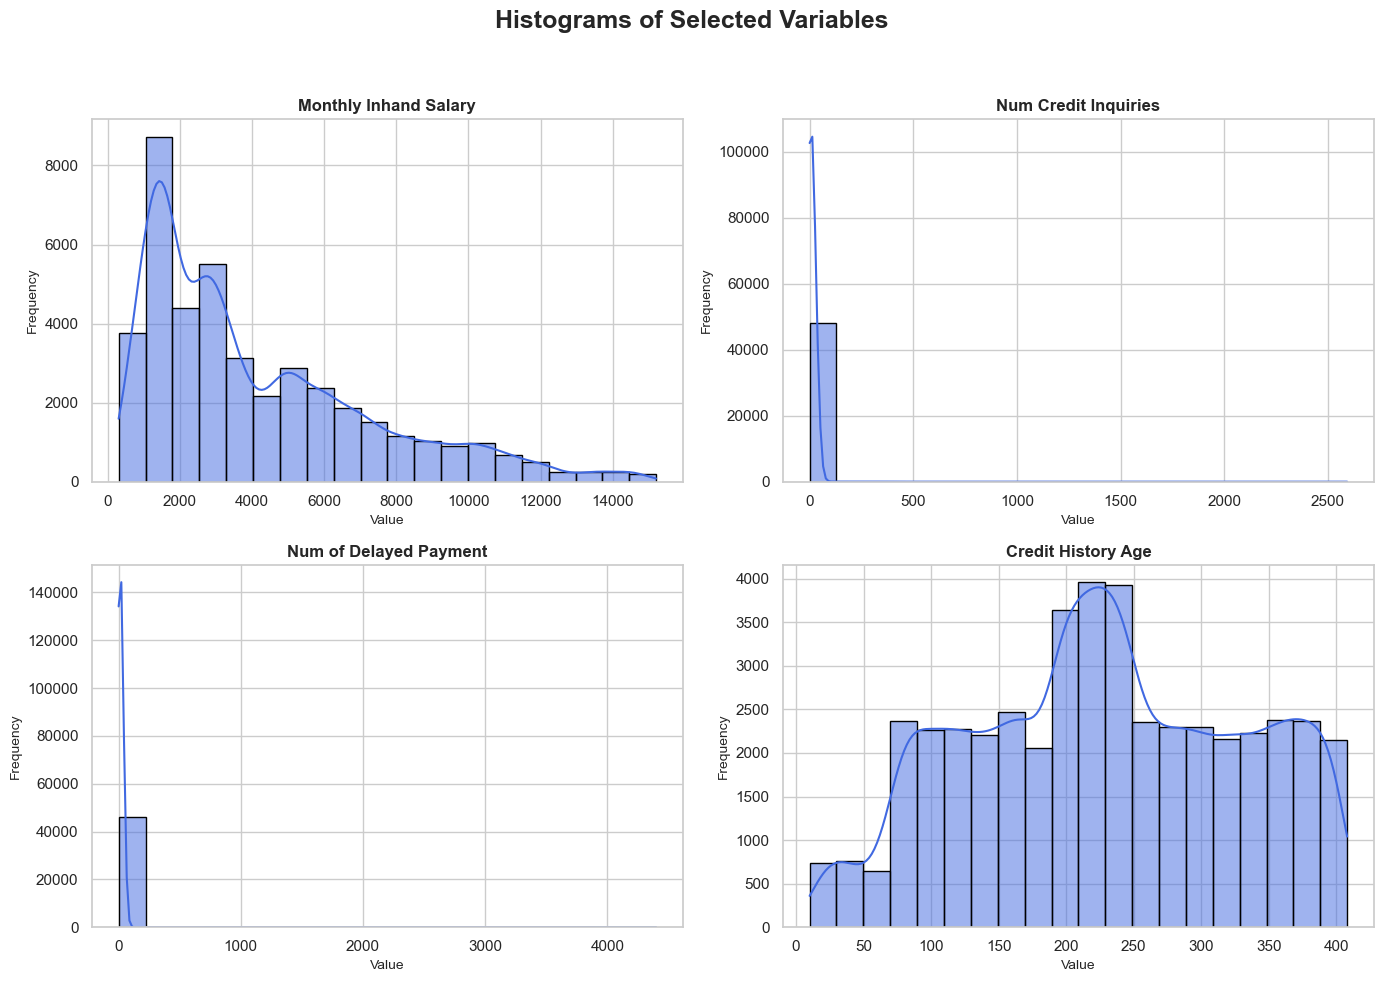

In [ ]:
# List of columns to plot
columns = ['Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age']
titles = ['Monthly Inhand Salary', 'Num Credit Inquiries', 'Num of Delayed Payment', 'Credit History Age']

# Set up the style for a clean and professional look
sns.set(style="whitegrid")  # Use seaborn white grid style

# Create subplots: 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Larger figure size for better presentation
fig.suptitle("Histograms of Selected Variables", fontsize=18, fontweight='bold', y=0.98)

# Loop through each column and create a histogram
for ax, col, title in zip(axes.flat, columns, titles):
    sns.histplot(datawithoutimputation[col], bins=20, kde=True, color='royalblue', edgecolor='black', ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)  # Correct method
    ax.set_ylabel('Frequency', fontsize=10)  # Correct method

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the overall title
plt.show()

We have used the `sns.histplot()` command from the `seaborn` package. Here, we wanted to create a **2x2 grid** of subplots so all four histograms can appear in a single figure. To do this, we specify `plt.subplots(2, 2)` and then select the overall figure size for better quality using the `figsize=(14, 10)`.The `sns.histplot()` plots the histogram of the selected columns. If you want to add a **Kernel Density Estimate (KDE)** curve,  state `True` in the `kde= ()`. Then, if you want to adjust the spacing between subplots to prevent any overlap, you can use the `plt.tight_layout(rect=[])`. At the end, do not forget to apply the `plt.show()` function that renders the figure with all histograms. 



#### 
[//]: # (-.- .unlisted .unnumbered)

---


We get important information just by looking at the histograms of these four variables. 
- The distribution of the `Monthly_Inhand_Salary` is positively skewed (right-skewed). This is because **most of the data points fall within lower salary ranges**, while a **small number of individuals have significantly higher salaries**.
- Most values for `Num_Credit_Inquiries` are extremely low (`close to 0`), with a massive concentration near the origin. The majority of individuals have **very few or no credit inquiries**. The extreme values might need further **investigation for outliers** (see above)
-  The distribution of `Num of Delayed Payment` is highly right-skewed. The significant concentration near zero suggests that delayed payments are rare for most individuals. The extreme values might need further **investigation for outliers** (see above)
-  The values for `Credit_History_Age` are distributed across the range but show noticeable peaks at certain intervals, such as between 100–150, 200–250, and near 350. The multiple peaks might indicate groups of individuals with similar credit history lengths.

So, let's investigate whether these speicifc variables encounter any outliers graphically.

In [ ]:
(
    ggplot(datawithoutimputation, aes(x = 'Month', y = 'Monthly_Inhand_Salary')) + 
        geom_boxplot() + 
        theme_classic() +
        labs(y = "Monthly Inhand Salary", x = "", title ="Boxplot for Monthly Inhand Salary (by month)")
 )

> The box indicates the position of the first and third quartiles (the 25th and 75th percentiles). The line in the middle of the box represents the median. The upper whisker extends from the 75th percentile to the largest value no further than 1.5 * IQR larger than the 75th percentile (where IQR is the inter-quartile range, or distance between the first and third quartiles). The lower whisker extends from the 25th percentile to the smallest value at most 1.5 * IQR of the hinge. Data beyond the end of the whiskers are called "outlying" points and are plotted individually.

The values labelled "outliers" by the `geom_boxplot` function are not necessarily to be treated as outliers. Here we are looking at income data and we know that they can be significantly right-skewed. The above plots do not indicate any concerns with real outliers.

Let's apply the same method for `num_Credit_Queries`.

In [63]:
(
    ggplot(datawithoutimputation, aes(x = 'Month', y = 'Num_Credit_Inquiries')) + 
        geom_boxplot() + 
        theme_classic() +
        labs(y = "Number of Credit Queries", x = "", title ="Boxplot for Number of Credit Queries (by month)")
 )

Here you can see that there are significant outliers. There are, relative to the values outlined in the boxplot so large that the boxplot is actually so much squished together that it has almost disappeared at the bottom of the graph. You will find a similar pattern for `Num_of_Delayed_Payment`. 

There is no general rule that can be applied here. For a particular problem you will have to investigate whether there is a good reason for the large values to represent actual valuable information or if there is a reason for you to remove these outliers.

It is vital to think carefully about this question. Let us demonstrate this using some analysis of the relationship between `Num_of_Delayed_Payment` and `Num_Credit_Inquiries`. We begin by producing a scatter diagram of these two variables.

In [71]:
(
    ggplot(datawithoutimputation, aes(x = 'Num_of_Delayed_Payment', y = 'Num_Credit_Inquiries')) + 
        geom_point() + 
        theme_classic() +
        labs(x = "Number of Delayed Payments", y = "Number of Credit Inquiries", title ="Relationship between Delayed Payments and Credit Enquiries (all)")
 )

This image is clearly dominated by the observations which contain potential outliers for either of the two variables. There will be a lot of observations "hiding" in the bottom left corner of the graph. To make them visible you can use the `geom_jitter` function which randomises the points placement. In the code below experiment with different values for the parameters (`height = 200, width = 200, size = 0.3`) to figure out what these do.

In [72]:
(
    ggplot(datawithoutimputation, aes(x = 'Num_of_Delayed_Payment', y = 'Num_Credit_Inquiries')) + 
        geom_jitter(height = 200, width = 200, size = 0.5) + 
        theme_classic() +
        labs(x = "Number of Delayed Payments", y = "Number of Credit Inquiries", title ="Relationship between Delayed Payments and Credit Enquiries (all), jittered")
 )

And let's also look at the correlation using the `corr()` method.

In [103]:
datawithoutimputation[['Num_of_Delayed_Payment','Num_Credit_Inquiries']].corr()

,Num_of_Delayed_Payment,Num_Credit_Inquiries
Num_of_Delayed_Payment,1.000000,-0.008382
Num_Credit_Inquiries,-0.008382,1.000000


The fact that we find a solid black plot in the bottom-left corner indicates that there are lots of observations in that area. The oddly rectangular shaped distributions also indicate that we are looking at some randomly generated data here. The correlation between the two variables is basically 0 when calculated on the basis of the full dataset.

## Dealing with outliers

Let's repeat this exercise without the oddly inflated observations. Above we figured out that `Num_Credit_Inquiries` > 20 and`Num_of_Delayed_Payment` > 30 are very rare. So let's exclude these. As this is an artificially generated dataset we expect that these have been included to emulate incorrect data entries.

In [203]:
data_wo_outliers = datawithoutimputation.query(('Num_of_Delayed_Payment < 31 and Num_Credit_Inquiries < 21')).copy() 

(
    ggplot(data_wo_outliers, aes(x = 'Num_of_Delayed_Payment', y = 'Num_Credit_Inquiries')) + 
        geom_jitter(height = 0.5, width = 0.5, size = 0.5) + # jitter is still useful as all observations are integers,
        theme_classic() +
        labs(x = "Number of Delayed Payments", y = "Number of Credit Inquiries", 
             title ="Relationship between Delayed Payments and Credit Enquiries (all), jittered")
 )

And if we now look at the correlation we note that it is significantly positive. 

In [120]:
data_wo_outliers[sel_columns].corr()

,Monthly_Inhand_Salary,Num_Credit_Inquiries,Num_of_Delayed_Payment,Credit_History_Age
Monthly_Inhand_Salary,1.000000,-0.274637,-0.285264,0.273827
Num_Credit_Inquiries,-0.274637,1.000000,0.491309,-0.601484
Num_of_Delayed_Payment,-0.285264,0.491309,1.000000,-0.483301
Credit_History_Age,0.273827,-0.601484,-0.483301,1.000000


You could also check how many of the originally 50,000 observations are remaining.

In [121]:
data_wo_outliers.shape

(44367, 27)

So, although only a small proportion of the observations was removed, the correlation changed very significantly, demonstrating how important it can be to keep your eye open for observations that appear to be problematic. 

There is no general rule that can tell you which observations are problematic and should be removed from your analysis. You will have to apply your domain knowledge to make such decisions. The type of analysis applied above can help you in that process.

Recall that we had four observations for every individual. In such a case, removing all these observations may not be optimal as the imputation techniques introduced in the next section may help. We therefore create a second dataset in which we merely replace the large values for `Num_of_Delayed_Payment` and `Num_Credit_Inquiries` with missing values. For this purpose we create a new dataset called `data_rem_outliers`. We use the `np.nan` to create missing values.

In [ ]:
data_rem_outliers = datawithoutimputation.copy()

data_rem_outliers.loc[data_rem_outliers['Num_of_Delayed_Payment'] > 30,'Num_of_Delayed_Payment'] = np.nan
data_rem_outliers.loc[data_rem_outliers['Num_Credit_Inquiries'] > 20,'Num_Credit_Inquiries'] = np.nan    

We can now check the summary statistics and should find sensible maximum values for the `Num_Credit_Inquiries` and `Num_of_Delayed_Payment`.

In [ ]:
data_rem_outliers[sel_columns].describe().round(2)

,Annual_Income,Monthly_Inhand_Salary,Num_Credit_Inquiries,Num_of_Delayed_Payment,Credit_History_Age
count,50000.00,42502.00,48119.00,46107.00,45530.00
mean,166334.20,4182.00,7.29,13.34,227.25
std,1351965.47,3174.11,3.95,6.26,99.55
min,7005.93,303.65,0.00,0.00,10.00
25%,19453.33,1625.19,4.00,9.00,151.00
50%,37577.82,3086.30,7.00,14.00,225.00
75%,72817.02,5934.19,10.00,18.00,307.00
max,24137255.00,15204.63,17.00,28.00,408.00


Now we will return to investigating the `Annual_Income` variable and whether the values observed are reasonable or whether any should be considered outliers or misreported values.

In [206]:
(
    ggplot(data_rem_outliers,aes(x = 'Annual_Income')) + 
        geom_histogram() +
        theme_classic() +
        labs(x = "Annual Income", y = "", title ="Distribution for Annual Income")
 )

This looks very similar to the previous pattern where we decided that there were outliers/misreported values. The following plot restricts the range of the x-axis.

In [162]:
(
    ggplot(data_rem_outliers,aes(x = 'Annual_Income')) + 
        geom_histogram() + xlim(0,500000) +
        theme_classic() +
        labs(x = "Annual Income", y = "", title ="Distribution for Annual Income")
 )

This does now look as if values above 200,000 are extremely rare. It may be best to look at a customer with very large `Annual_Income`.

In [207]:
test_sal = np.max(data_rem_outliers['Annual_Income'])
test_sal
sel_id = data_rem_outliers.query('Annual_Income >22000000')
sel_id.head()


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
2323,0x313d,CUS_0xaf5f,December,Raymondy,22.0,512-99-1299,Scientist,24112304.0,6966.975000,2,...,7.0,Good,1457.34,29.136087,264.0,No,0.000000,126.996040,High_spent_Large_value_payments,809.7014602969257
3128,0x3ab2,CUS_0x8c1d,September,Howleyr,27.0,916-54-9792,Lawyer,22896455.0,9983.400000,7,...,9.0,Standard,514.91,31.195179,238.0,Yes,193.537726,119.827107,High_spent_Large_value_payments,924.9751666389543
4005,0x44f7,CUS_0x5d05,October,Horowitzj,35.0,823-01-2017,Scientist,22659411.0,2160.049167,6,...,2.0,Standard,787.21,39.027313,197.0,No,64.970760,121.871878,Low_spent_Small_value_payments,319.16227931559445
4842,0x4ec4,CUS_0x6672,November,Elinorp,48.0,096-10-4575,Lawyer,22016015.0,NaN,3,...,0.0,Standard,1447.93,25.682315,391.0,Yes,29.295467,205.641411,Low_spent_Small_value_payments,231.3444562343999
4978,0x505c,CUS_0x523b,November,Karen Freifeldg,46.0,967-55-6862,Developer,22444909.0,3539.822837,2,...,5.0,Good,59.06,41.503399,NaN,No,252.344663,81.979933,High_spent_Large_value_payments,537.2368174


We selected only those observations for which the Annual Income is larger than 22,000,000. You can tell that these all seem to be isolated observations for each customer, meaning there seems to be no customer who has such a high annual income for all months. This seems to indicate that these high annual incomes are not sensible values. Let;s pick one of these customers ("CUS_0xaf5f") and look at all their observations.

In [ ]:
data_rem_outliers.loc[data_rem_outliers['Customer_ID'] == "CUS_0xaf5f",:]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
2320,0x313a,CUS_0xaf5f,September,Raymondy,22.0,512-99-1299,Scientist,85667.7,6966.975,2,...,3.0,Good,1457.34,44.452171,261.0,No,0.0,57.570633,High_spent_Large_value_payments,879.1268667165469
2321,0x313b,CUS_0xaf5f,October,Raymondy,22.0,512-99-1299,Scientist,85667.7,6966.975,2,...,7.0,_,1457.34,32.746509,262.0,No,0.0,52.045091,High_spent_Large_value_payments,884.6524091245541
2322,0x313c,CUS_0xaf5f,November,Raymondy,22.0,512-99-1299,Scientist,85667.7,6966.975,2,...,7.0,Good,1457.34,35.734582,263.0,No,0.0,125.560207,High_spent_Large_value_payments,811.1372932674901
2323,0x313d,CUS_0xaf5f,December,Raymondy,22.0,512-99-1299,Scientist,24112304.0,6966.975,2,...,7.0,Good,1457.34,29.136087,264.0,No,0.0,126.996040,High_spent_Large_value_payments,809.7014602969257


As you can see here, the `Monthly_Inhand_Salary` for this customer does not change and the December observation does not seem a reasonable observation. This judgement is confirmed by the values for the customers balance and invested amount.

This now begs the question how to identify the values we wish to treat as outliers and replace by missing values. There is no one correct answer here. One way to identify such values would be by comparing the Annual Salary to the sum of `Monthly_Inhand_Salary` + `Amount_invested_monthly`. When calculating `Annual_Income` / ( `Monthly_Inhand_Salary`+`Amount_invested_monthly`) we should get values in the order of magnitute of 12. If that value is much larger than 12 we can consider the `Annual_Income` value to not be a reliable observation.

In [ ]:
data_rem_outliers['test'] = data_rem_outliers['Annual_Income']/(data_rem_outliers['Monthly_Inhand_Salary']+data_rem_outliers['Amount_invested_monthly']) 

Now we will check the distribution of the new `test` variable. Recall we expect values around 12.

In [ ]:
(
    ggplot(data_rem_outliers,aes(x = 'test')) + 
        geom_histogram() + 
        theme_classic() +
        labs(x = "Ration of Annual income to monthly income and saving", y = "", 
             title ="Distribution for Ration of Annual income to monthly income and saving")
 )

From the scale of the histogram (which is determined by the variable's minimum and maximum value) you can tell that there are some very large values. The next histogram shows the histogram of test values up to 50.

In [214]:
(
    ggplot(data_rem_outliers,aes(x = 'test')) + 
        geom_histogram() + xlim(0,50) +
        theme_classic() +
        labs(x = "Ration of Annual income to monthly income and saving", y = "", 
             title ="Distribution for Ration of Annual income to monthly income and saving")
 )

You can see that the vast number of values is in the 10 to 15 range. Let's decide that any values larger than 25 are not sensible and hence we shall replace the associated values to `Annual_Income` to missing values.

In [215]:
data_rem_outliers.loc[data_rem_outliers['test'] > 25,'Annual_Income'] = np.nan  

It is important to understand that this does not rule out large values of `Annual_Income`, only those that are not consistent with the monthly available income and monthly investment numbers. There would have been other ways to identify outliers. For instance we could have identified annual income values which are significantly different to the annual income values of the  same customer in the other months.

## Dealing with missing values

Previously we discovered that there are a number of missing values in a number of variables. We repeat the analysis on our new datasets, `data_wo_outliers` (removed observations with outlier observations for credit queries and delayed payments) and `data_rem_outliers` (replaced observations with outlier observations for credit queries and delayed payments with missing values).

In [216]:
# Calculate missing values per variable
missing_values = data_rem_outliers.isnull().sum() # you replace data_rem_outliers with data_wo_outliers

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(data_wo_outliers)) * 100

# Combine into a DataFrame for better visualization
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

# Display the summary
print(missing_summary)

                          Missing Values  Percentage (%)
test                                9421       21.234251
Monthly_Inhand_Salary               7498       16.899948
Type_of_Loan                        5704       12.856402
Name                                5015       11.303446
Credit_History_Age                  4470       10.075056
Num_of_Delayed_Payment              3893        8.774540
Amount_invested_monthly             2271        5.118669
Num_Credit_Inquiries                1881        4.239638
Monthly_Balance                      562        1.266707
Annual_Income                        407        0.917348
Payment_Behaviour                      0        0.000000
Total_EMI_per_month                    0        0.000000
Payment_of_Min_Amount                  0        0.000000
Credit_Utilization_Ratio               0        0.000000
Outstanding_Debt                       0        0.000000
Credit_Mix                             0        0.000000
ID                             

There are three popular schemes that deal with missing values:

1.	**Delete the missing values**: This action implies that we loose at least 15% of the data. It is important to understand whether the observations are missing randomly. If they are not, then removing the observations can be problematic.
2.	**Keep the missing values**, because they might be meaningful. Here we would accept, however, that some analysis will either not be done as it cannot be done with missing values or that some analysis is done by excluding observations with missing values.
3.	**Replace (Impute)**: This involves replacing the missing value with a known value.


> For a thorough understanding of handling  missing values and mastering data mining techniques the following resources offer valuable insights:
> - [Berry and Linoff (2004)](https://pzs.dstu.dp.ua/DataMining/bibl/Data%20Mining%20Techniques%20For%20Marketing%20Sales%20And%20Customer%20Relationship%20Management%202Ed.pdf),
> - [Wilet et al. (2020)](https://link.springer.com/article/10.1007/s11336-022-09856-8)
> - [Coding  for Economists by Arthur Turrell](https://aeturrell.github.io/coding-for-economists/intro.html)

Let's decide to impute some of the missing values and lets also decide to continue working on the `data_rem_outliers` dataset. An excellent introduction to data imputation is available from [Arthur Turrell's chapter](https://aeturrell.github.io/coding-for-economists/ml-data.html#imputing-missing-values) on imputing values. We can proceed to a median imputation meaning that missing values will be replaced with the median value of the respective variable. To perform imputation, we will need to import the `sklearn.impute` function from the `sklearn` package.

In [124]:
from sklearn.impute import SimpleImputer

In [137]:
# Define the columns for which we wish to impute values
numeric_columns = ['Num_of_Delayed_Payment', 
                   'Credit_History_Age', 
                   'Num_Credit_Inquiries', 
                   'Monthly_Inhand_Salary']

# Create a separate copy of the original data for median imputation
data_median_imputed = data_rem_outliers.copy()

# Create a SimpleImputer object with median strategy
median_imputer = SimpleImputer(strategy='median')

# Apply the imputer to the numeric columns in the copied dataset
data_median_imputed[numeric_columns] = median_imputer.fit_transform(data_median_imputed[numeric_columns])

# Verify if all missing values have been imputed
print("Missing values after median imputation:")
print(data_median_imputed[numeric_columns].isnull().sum())


Missing values after median imputation:
Num_of_Delayed_Payment    0
Credit_History_Age        0
Num_Credit_Inquiries      0
Monthly_Inhand_Salary     0
dtype: int64


The necessary step here is for you to create the "Imputer". In this case, you are creating a median imputer using `median_imputer = SimpleImputer(strategy='median')`, which replaces all missing values with the median of each column. Then you apply the imputation using the `.fit_transform` method. Then you can confirm that all missing values have been replaced (resulting in 0 missing values) by running the `print(data_median_imputed[numeric_columns].isnull().sum())` command.

You could compare the distributions of the variables before and after imputing. However, in this case, the results is obvious. You should see that there are additional observations at the median value.

This is imputation method is really straightforward, but sometimes it is not as good as you can do. Let's look at a particular customer, in fact the first customer (`'Customer_ID' == "CUS_0xd40"`), which had a missing `Monthly_Inhand_Salary` for December. This should now be filled by the median for the `Monthly_Inhand_Salary` variable.

In [ ]:
data_median_imputed.loc[data_median_imputed['Customer_ID'] == "CUS_0xd40",:]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,7.0,Good,809.98,35.030402,273.0,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,274.0,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,225.0,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24.0,821-00-0265,Scientist,19114.12,3086.305000,3,...,4.0,Good,809.98,32.430559,276.0,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634


The imputed monthly income is now larger than the other monthly incomes although the respective annual income is unchanged. 

> Note however, that the monthly inhand salary is not just 1/12 of the annual income. We do not have precise information on either of the two variables. The inhand salary may actually include benefits received and may be less taxes paid. Also salaries may have changed during a year and we are not certain how that is reflected in the annual salary.

In a case like this we really would want to just impute the same value as this customer had for the other months.

In the next section we can will explore some more advanced imputation methods potentially addressing the issue just identified.

## Advanced Imputation techniques

While median imputation is straightforward it can be, as discussed above less than what we can do. Python offers a variety of powerful methods to deal with missing data. One of these methods involves the `K-Nearest Neighbors (KNN`) Imputation using  `KNNImputer` from `sklearn`. This imputation technique estimates missing values based on the values of the nearest neighbours. 


Following on from this discussion we will consider the following procedure. We are imputing missing values for `Monthly_Inhand_Salary` using the K-Nearest Neighbours (KNN) imputation technique. In particular we will find the $k$ observations (or nearest neighbors) which are closest to the `Annual_Income` and `Age` of the missing observation. Then we will impute the missing value by the average of the `Monthly_Inhand_Salary` observations of these $k$ nearest neighbors. This is implemented with the `KNNImputer` from the `sklearn.impute` package.

In the following we use $k=3$ as that should enable the algorithm to identify the three other observations for that customer.

In [240]:
from sklearn.impute import KNNImputer

# Create a copy of the original data for KNN Imputation
data_knn_imputed = data_rem_outliers.copy()

# Initialize KNNImputer
knn_imputer = KNNImputer(n_neighbors=2, weights='uniform')  # 3 nearest neighbors

# Apply KNN Imputer
data_knn_imputed['Monthly_Inhand_Salary'] = knn_imputer.fit_transform(data_knn_imputed[['Monthly_Inhand_Salary','Annual_Income','Age']])

# Verify if missing values have been imputed
print("Missing values after KNN Imputation:")
print(data_knn_imputed['Monthly_Inhand_Salary'].isnull().sum())

Missing values after KNN Imputation:
0


Now we can check how that missing December `Monthly_Inhand_Salary` value for customer "CUS_0xd40" was replaced.

In [241]:
data_rem_outliers.loc[data_rem_outliers['Customer_ID'] == "CUS_0xd40",:]


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,test
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,35.030402,273.0,No,49.574949,236.642682,Low_spent_Small_value_payments,186.26670208571772,9.272011
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,33.053114,274.0,No,49.574949,21.465380,High_spent_Medium_value_payments,361.44400385378196,10.352613
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,33.811894,NaN,No,49.574949,148.233938,Low_spent_Medium_value_payments,264.67544623342997,9.687467
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24.0,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,32.430559,276.0,No,49.574949,39.082511,High_spent_Medium_value_payments,343.82687322383634,NaN


In [242]:
data_knn_imputed.loc[data_knn_imputed['Customer_ID'] == "CUS_0xd40",:]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,test
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,35.030402,273.0,No,49.574949,236.642682,Low_spent_Small_value_payments,186.26670208571772,9.272011
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,33.053114,274.0,No,49.574949,21.465380,High_spent_Medium_value_payments,361.44400385378196,10.352613
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,33.811894,NaN,No,49.574949,148.233938,Low_spent_Medium_value_payments,264.67544623342997,9.687467
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24.0,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,32.430559,276.0,No,49.574949,39.082511,High_spent_Medium_value_payments,343.82687322383634,NaN


In [236]:
#3163.511389*3 - 1824.843333*2 = 5840.847501
data_rem_outliers.query('Monthly_Inhand_Salary >5840 and Monthly_Inhand_Salary <5842')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,test
6612,0x6386,CUS_0xa65f,September,Brownz,24.0,468-32-1247,_______,NaN,5840.8475,8,...,Standard,337.25,36.213207,305.0,Yes,93.188698,186.402464,High_spent_Small_value_payments,564.4935888445815,921.952471
6614,0x6388,CUS_0xa65f,November,Brownz,24.0,468-32-1247,Media_Manager,67726.17,5840.8475,8,...,Standard,337.25,37.058669,307.0,Yes,93.188698,260.267175,Low_spent_Medium_value_payments,510.6288777617524,11.100622
6615,0x6389,CUS_0xa65f,December,Brownz,25.0,468-32-1247,Media_Manager,67726.17,5840.8475,8,...,_,337.25,28.646595,308.0,Yes,93.188698,383.428160,Low_spent_Small_value_payments,397.4678927,10.880972
34664,0x1ac42,CUS_0x83a0,September,Matt Dailyg,42.0,640-44-9921,Doctor,69712.20,5841.3500,8,...,Standard,1638.94,36.901444,177.0,NM,275.125859,274.451647,High_spent_Small_value_payments,294.55749406819854,11.398702
34665,0x1ac43,CUS_0x83a0,October,Matt Dailyg,42.0,640-44-9921,Doctor,69712.20,5841.3500,8,...,Standard,1638.94,36.541859,178.0,Yes,275.125859,388.936352,High_spent_Small_value_payments,180.07278827559938,11.189245
34666,0x1ac44,CUS_0x83a0,November,Matt Dailyg,42.0,640-44-9921,Doctor,69712.20,5841.3500,8,...,Standard,1638.94,33.881928,NaN,NM,275.125859,128.060195,High_spent_Large_value_payments,420.94894552377417,11.678239
34667,0x1ac45,CUS_0x83a0,December,Matt Dailyg,42.0,640-44-9921,Doctor,69712.20,5841.3500,8,...,Standard,1638.94,27.167498,180.0,Yes,275.125859,115.159200,High_spent_Large_value_payments,433.8499409860981,11.703533


It was replaced by the same value as the September to October values, and seemed appropriate here as the annual income remained unchanged and hence there was no indication that the income actually had changed.

check line 50 and 294

Let's look at some other interesting cases to check whether this imputation did what we would expect. We start with customer "CUS_0x384c"

In [217]:
data_rem_outliers.loc[data_rem_outliers['Customer_ID'] == "CUS_0x384c",:]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,test
292,0x1976,CUS_0x384c,September,David Henryp,42.0,813-91-8749,Scientist,9841.34,690.111667,8,...,Bad,4984.82_,35.479267,61.0,Yes,36.675128,23.724285,!@9#%8,298.61175398115034,13.786557
293,0x1977,CUS_0x384c,October,David Henryp,42.0,813-91-8749,Scientist,9841.34,690.111667,8,...,_,4984.82,31.471032,62.0,Yes,36.675128,13.486314,!@9#%8,278.84972435570114,13.987164
294,0x1978,CUS_0x384c,November,NaN,42.0,813-91-8749,Scientist,9841.34,NaN,8,...,Bad,4984.82,27.201708,63.0,Yes,36.675128,16.913196,High_spent_Small_value_payments,275.4228427706929,NaN
295,0x1979,CUS_0x384c,December,David Henryp,42.0,813-91-8749,Scientist,NaN,690.111667,8,...,Bad,4984.82,35.850308,64.0,Yes,36.675128,30.935736,High_spent_Small_value_payments,261.40030309134585,14599.747487


In [218]:
data_knn_imputed.loc[data_knn_imputed['Customer_ID'] == "CUS_0x384c",:]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
292,0x1976,CUS_0x384c,September,David Henryp,42.0,813-91-8749,Scientist,9841.34,690.111667,8,...,10.0,Bad,4984.82_,35.479267,61.0,Yes,36.675128,23.724284766347083,!@9#%8,298.61175398115034
293,0x1977,CUS_0x384c,October,David Henryp,42.0,813-91-8749,Scientist,9841.34,690.111667,8,...,10.0,_,4984.82,31.471032,62.0,Yes,36.675128,13.486314391796205,!@9#%8,278.84972435570114
294,0x1978,CUS_0x384c,November,NaN,42.0,813-91-8749,Scientist,9841.34,734.879306,8,...,10.0,Bad,4984.82,27.201708,63.0,Yes,36.675128,16.913195976804445,High_spent_Small_value_payments,275.4228427706929
295,0x1979,CUS_0x384c,December,David Henryp,42.0,813-91-8749,Scientist,10527110.00,690.111667,8,...,10.0,Bad,4984.82,35.850308,64.0,Yes,36.675128,30.935735656151515,High_spent_Small_value_payments,261.40030309134585


As you can see above, this has indeed imputed the December `Monthly_Inhand_Salary` with 

The `n_neighbors=5` in the `KNNImputer` function measn that it uses the average of the 5 nearest neighbors to impute missing values whereas the `weights='uniform'` indicates that all neighbours contribute equally to the imputation. It is important to create a separate dataset for the KNN Imputation so we can compare it to the original one. What actually applies the KNN imputer to the selected columns is the `fit_transform()` command. From the outpu provided, we can see that with the KNN imputation, the number of missing values for the variables on interest is zero.

### Second step: Plot histograms to compare before and after KNN imputation

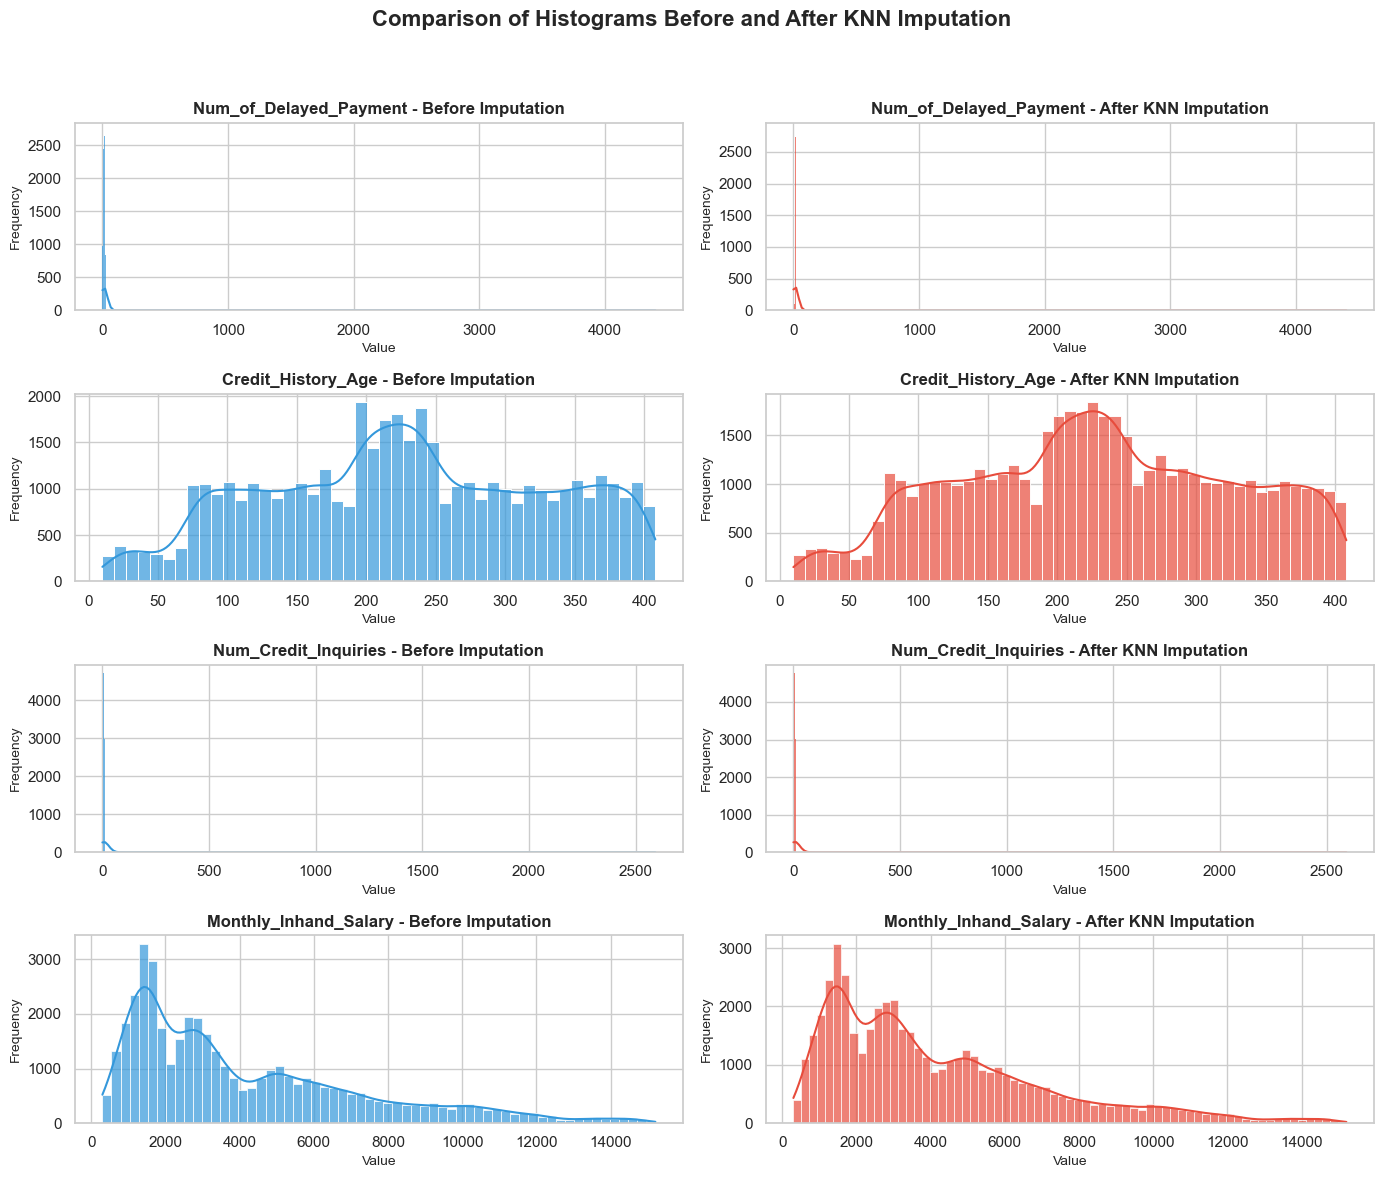

In [158]:
# Compare Histograms Before and After KNN Imputation
fig, axes = plt.subplots(4, 2, figsize=(14, 12))  # 4 rows, 2 columns
fig.suptitle("Comparison of Histograms Before and After KNN Imputation", fontsize=16, fontweight='bold', y=0.98)

# Define colors
before_color = "#3498DB"  # Blue for before imputation
after_color = "#E74C3C"   # Red for after KNN imputation

# Loop through each column
for i, col in enumerate(columns_to_impute):
    # Plot Before Imputation
    sns.histplot(datawithoutimputation[col].dropna(), kde=True, ax=axes[i, 0], color=before_color, alpha=0.7)
    axes[i, 0].set_title(f"{col} - Before Imputation", fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel("Value", fontsize=10)
    axes[i, 0].set_ylabel("Frequency", fontsize=10)

    # Plot After KNN Imputation
    sns.histplot(data_knn_imputed[col], kde=True, ax=axes[i, 1], color=after_color, alpha=0.7)
    axes[i, 1].set_title(f"{col} - After KNN Imputation", fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel("Value", fontsize=10)
    axes[i, 1].set_ylabel("Frequency", fontsize=10)

# Adjust the layout for readability
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Now that we have plotted the histograms before and after KNN imputation, it’s your turn to take the lead! Take this opportunity to critically interpret the results and strengthen your understanding of imputation techniques.

## Summary

In this section, we demonstrated key data preprocessing steps to ensure the dataset is clean, complete, and ready for analysis. Beginning with **data exploration and preparation**, we identified issues such as incorrect data types and missing values, which were resolved through data cleaning and conversion into appropriate numeric formats. During **exploratory data analysis (EDA)**, we examined variable distributions, identified outliers using histograms and boxplots, and explored relationships through scatterplots and a correlation heatmap, revealing weak correlations between variables. Finally, we **addressed missing values** using median and the KNN Imputation,  robust approaches suited for skewed data and outliers. These preprocessing steps have systematically prepared the dataset for the next phase of analysis or modelling, ensuring its integrity and reliability.